In [1]:
import json
import pandas as pd
import numpy as np

#data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/preprocess/ALC_features_Functional.json'

# data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/features/'

data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/features/currently_used/V2_full_orig_vt/speaker_normalised/'


In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
# df = pd.read_json(data_path, orient='index')
# df.head()

In [4]:
# from sklearn.model_selection import train_test_split

# train, test = train_test_split(df, test_size=0.2)

In [5]:
import os

train_df = pd.read_json(os.path.join(data_path, 'V2_bal_subset_Functional_full_normalised_train.json'), orient='index')
valid_df = pd.read_json(os.path.join(data_path, 'V2_bal_subset_Functional_full_normalised_valid.json'), orient='index')
test_df = pd.read_json(os.path.join(data_path, 'V2_bal_subset_Functional_full_normalised_test.json'), orient='index')

In [6]:
print (f'''Train contains {len(train_df)} examples. 
Test contains {len(test_df)} examples. 
Valid contains {len(valid_df)} examples.''')

Train contains 1604 examples. 
Test contains 972 examples. 
Valid contains 972 examples.


In [7]:
train_df['features'][0]

{'F0semitoneFrom27.5Hz_sma3nz_amean': [-1.228767028522001],
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm': [-1.081009817677524],
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0': [0.313908768020138],
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': [-1.299726446940245],
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0': [-1.283041665876299],
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2': [-1.192321908631998],
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope': [0.031587729787141],
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope': [-0.37344683088364106],
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope': [-0.514256933425837],
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope': [0.45804381533985206],
 'loudness_sma3_amean': [0.7096297575172451],
 'loudness_sma3_stddevNorm': [-0.296355301702434],
 'loudness_sma3_percentile20.0': [1.059401187797239],
 'loudness_sma3_percentile50.0': [0.7086909694161431],
 'loudness_sma3_percentile80.0': [0.472714409917998],
 'loudness_sma3_pctlrange0-2': [0.187590627700876],
 '

In [8]:
train = train_df
valid = valid_df
test = test_df

# Majority Baseline 
(Just one dummy feature)

In [9]:
# this keeps one first feature -- should not be informative enough for the model to work
def features_to_vec(feature_dict):
#     out_vector = []
#     for feature in feature_dict.values():
#         out_vector.append(feature)
    return [0]

In [10]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[5])} dimensions.")

The dataset has 1604 data samples.
Each data sample is a vector of 1 dimensions.


In [11]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

# X_test = test['features'].apply(features_to_vec).tolist() 
# y_test = [label_to_idx[x] for x in test['intoxicated']]

X_test = valid['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in valid['intoxicated']]

In [12]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [13]:
X_train[2:4]
#look at this; maybe we could collapse redundant features? like do PCA or any other dimensionality reduction

[[0], [0]]

In [14]:
y_train[:2]

[1, 1]

In [15]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [16]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)
accuracy = nb_classifier.score(X_test, y_test)
accuracy

0.5483539094650206

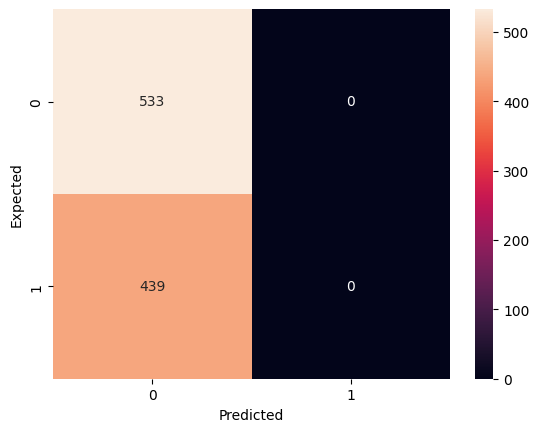

In [17]:
evaluate_classifier(nb_classifier, X_test, y_test)

# Actual Baseline

In [18]:
# this simply flattens all the features into one long concatenated vector
def features_to_vec(feature_dict):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

features_to_vec(train['features'][0])

[-1.228767028522001,
 -1.081009817677524,
 0.313908768020138,
 -1.299726446940245,
 -1.283041665876299,
 -1.192321908631998,
 0.031587729787141,
 -0.37344683088364106,
 -0.514256933425837,
 0.45804381533985206,
 0.7096297575172451,
 -0.296355301702434,
 1.059401187797239,
 0.7086909694161431,
 0.472714409917998,
 0.187590627700876,
 0.317981986642834,
 0.592567818428248,
 0.738309747500491,
 0.38555269026314704,
 0.140977426749289,
 -0.134667829149206,
 -0.307311920914633,
 0.339901630058759,
 -0.6641120863471971,
 0.35617966578138205,
 0.358819830282861,
 -0.47379686761516504,
 0.814532852067933,
 -0.266962863469552,
 -0.5116081450427951,
 1.148909174872594,
 -0.491454555875224,
 0.469963691961338,
 -0.0035298996381570003,
 0.155052607633614,
 -0.62405058699171,
 0.7574611900934041,
 -0.20825982901991802,
 0.595550747854808,
 0.44871883934286705,
 1.262531602966836,
 -0.146881324228524,
 0.7854903173033141,
 0.547728173641418,
 -0.5373657554477861,
 -0.28005947348958005,
 0.0847503670

In [19]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[7])} dimensions.")

The dataset has 1604 data samples.
Each data sample is a vector of 88 dimensions.


In [20]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = valid['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in valid['intoxicated']]

In [21]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [22]:
#([set([type(x) for x in y]) for y in X_train])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [23]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)
accuracy = nb_classifier.score(X_test, y_test)
accuracy

0.6296296296296297

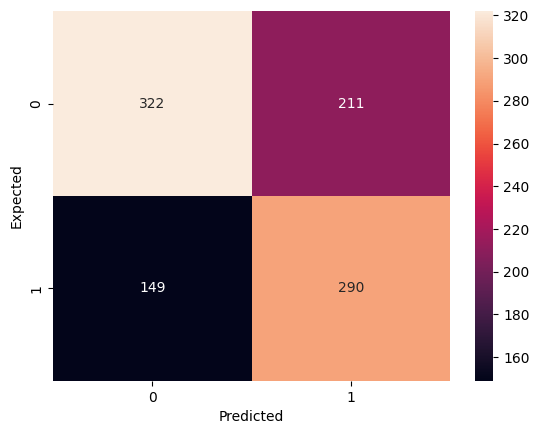

In [24]:
evaluate_classifier(nb_classifier, X_test, y_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [26]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
accuracy = knn_classifier.score(X_test, y_test)
accuracy

0.6141975308641975

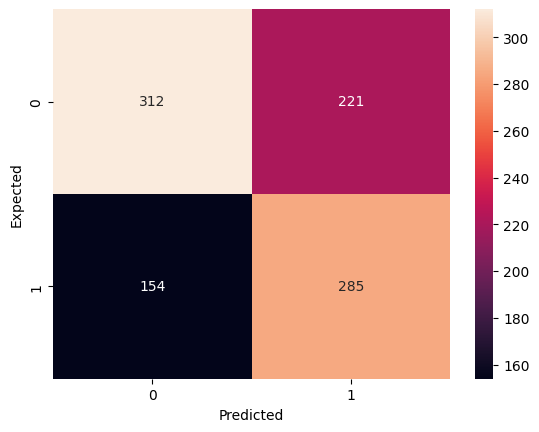

In [27]:
evaluate_classifier(knn_classifier, X_test, y_test)

In [28]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
accuracy = rf_classifier.score(X_test, y_test)
accuracy 

0.6635802469135802

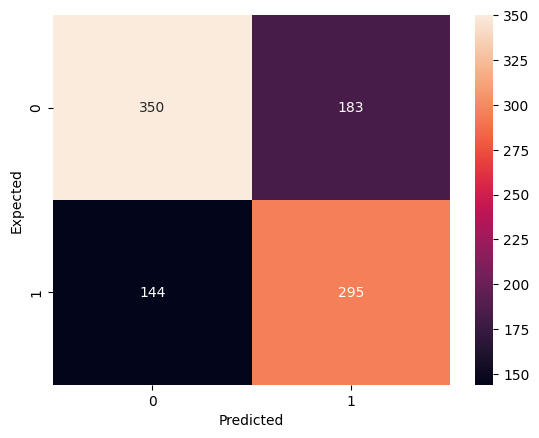

In [29]:
evaluate_classifier(rf_classifier, X_test, y_test)

In [30]:
svm_classifier = svm.LinearSVC()
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/NLP4/lib64/python3.10/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.6388888888888888

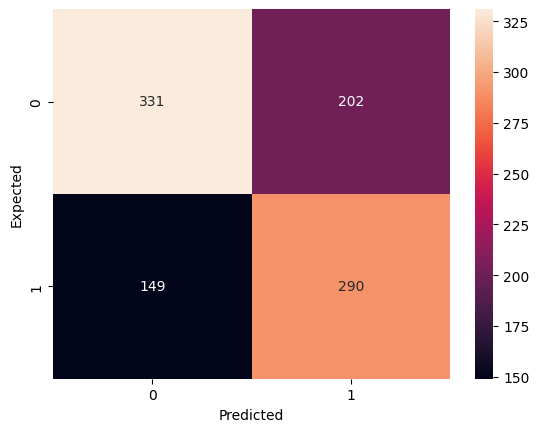

In [31]:
evaluate_classifier(svm_classifier, X_test, y_test)

In [32]:
svm_classifier = svm.NuSVC(kernel='poly')
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

0.6574074074074074

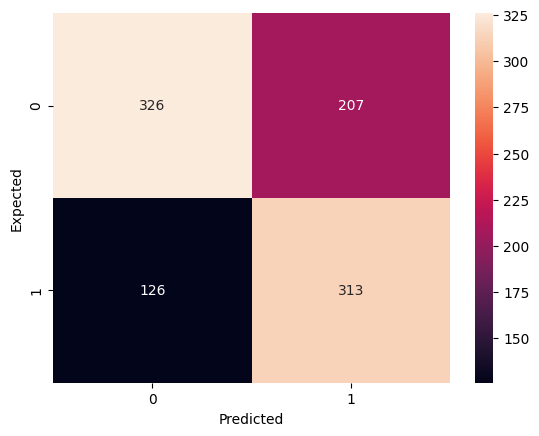

In [33]:
evaluate_classifier(svm_classifier, X_test, y_test)

In [34]:
logreg_classifier = LogisticRegression()
logreg_classifier.fit(X_train, y_train)
accuracy = logreg_classifier.score(X_test, y_test)
accuracy

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/NLP4/lib64/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6378600823045267

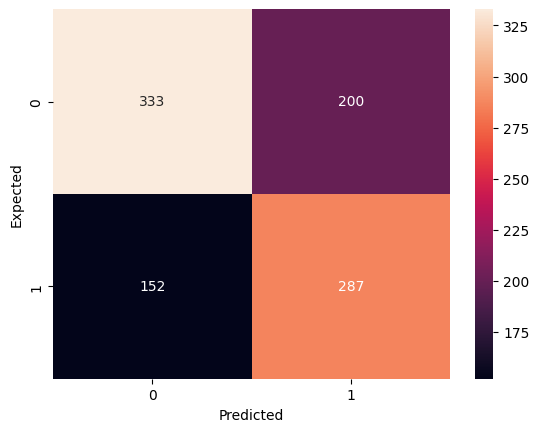

In [35]:
evaluate_classifier(logreg_classifier, X_test, y_test)

# Majority Baseline for the Levels (Regression Task)

In [36]:
from sklearn import linear_model

In [37]:
linmodel = linear_model.LinearRegression(fit_intercept=True)

In [38]:
def features_to_vec(feature_dict, i=0):
    out_vector = [list(feature_dict.values())[i][0]] #first of i-th feature only
    return out_vector

X_train = train['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)

LinearRegression()

In [39]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

-2.2344158356347844e-06 0.00044400249376558607


In [40]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 0.00
Coefficient of determination: -0.01


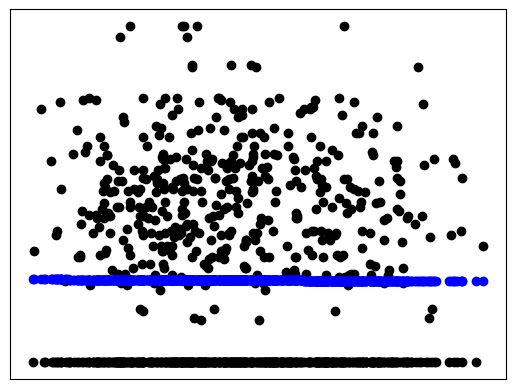

In [41]:
import matplotlib.pyplot as plt
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [42]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = valid['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur

68 0.018224441698947214
Mean squared error: 0.00
Coefficient of determination: 0.02


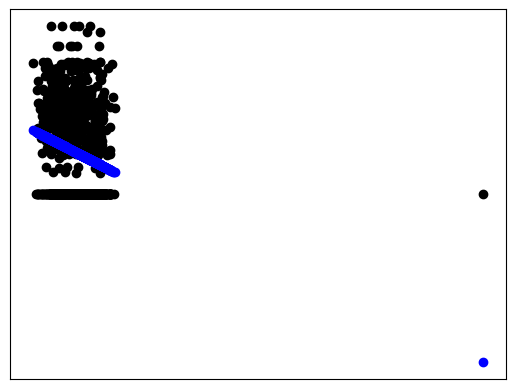

In [43]:
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

## On only those who have non-0 alc level
### In the breath
Feature 38 seems to be correlated with the alcohol level in blood

68 0.018224441698947214
Mean squared error: 0.00
Coefficient of determination: 0.02


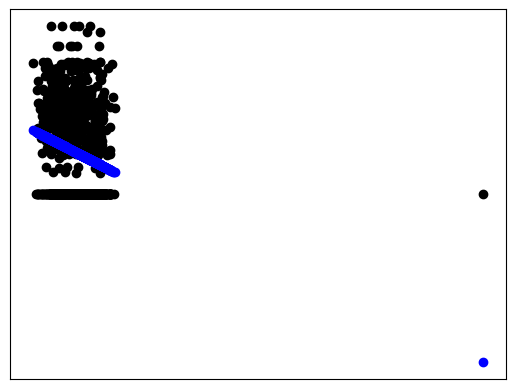

In [44]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = valid['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

In [45]:
!pwd

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/CLTeamLab/intoxicat/baselines
